### Implementing simple Chatbot Using LangGraph

In [1]:
from langgraph.graph.message import add_messages, AnyMessage
from langgraph.graph import StateGraph, START, END
from typing import Annotated
from pydantic import BaseModel

class state(BaseModel):
    messages: Annotated[list[AnyMessage],add_messages]

In [2]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")

In [3]:
from langchain_openai import ChatOpenAI
llm=ChatOpenAI(model="gpt-4o")

/home/aniruddha/Projects/RAG/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### We Will start With Creating Nodes

In [4]:
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()

def superbot(state: state) -> state:
   return {"messages": [llm.invoke(state.messages)]}


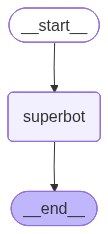

In [6]:
graph = StateGraph(state)

graph.add_node("superbot", superbot)

graph.add_edge(START, "superbot")
graph.add_edge("superbot", END)

graph_builder = graph.compile(checkpointer=memory)

from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [7]:
# invocation
config = {"configurable":{"thread_id":"1"}}
graph_builder.invoke({"messages":"Hello, my name is sachin and I like cricket"},config=config)

{'messages': [HumanMessage(content='Hello, my name is sachin and I like cricket', additional_kwargs={}, response_metadata={}, id='3dc32e84-8cf8-4308-afec-73bebbf8ddb9'),
  AIMessage(content="Hi Sachin! It's great to meet someone who enjoys cricket. Do you have a favorite team or player?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 22, 'prompt_tokens': 18, 'total_tokens': 40, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_a0e9480a2f', 'id': 'chatcmpl-D19vq88PdoDrvftcG8jOlYPmTYOBM', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019beaae-b8bf-7802-87be-4f6316d9922d-0', usage_metadata={'input_tokens': 18, 'output_tokens': 22, 'total_tokens': 40, 'input_token_de

### Streaming 
Methods: .stream() and astream()

- These methods are sync and async methods for streaming back results.

Additional parameters in streaming modes for graph state

- **values** : This streams the full state of the graph after each node is called.
- **updates** : This streams updates to the state of the graph after each node is called.

<div style="text-align:center">
  <img src="../assets/stream_astream.png">
</div>

#### Streaming The Responses With Stream Method

In [8]:
# Create a thread
config = {"configurable": {"thread_id": "3"}}

for chunk in graph_builder.stream({"messages":"Hello, my name is aniruddha and I like football"},config=config,stream_mode="updates"):
    print(chunk)

{'superbot': {'messages': [AIMessage(content="Hello Aniruddha! It's great to meet you. Football is an exciting sport with a huge global following. Do you have a favorite team or player?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 32, 'prompt_tokens': 20, 'total_tokens': 52, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_a0e9480a2f', 'id': 'chatcmpl-D19zATFnHzFUWUFoG2v9VHrkWdhby', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019beab1-dd23-77f0-9100-ae229cb5dd79-0', usage_metadata={'input_tokens': 20, 'output_tokens': 32, 'total_tokens': 52, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})]}}


In [9]:

for chunk in graph_builder.stream({"messages":"Hello, my name is aniruddha and I like football"},config=config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hello, my name is aniruddha and I like football', additional_kwargs={}, response_metadata={}, id='658eb078-7545-44f4-8ec2-a0e487d5e752'), AIMessage(content="Hello Aniruddha! It's great to meet you. Football is an exciting sport with a huge global following. Do you have a favorite team or player?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 32, 'prompt_tokens': 20, 'total_tokens': 52, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_a0e9480a2f', 'id': 'chatcmpl-D19zATFnHzFUWUFoG2v9VHrkWdhby', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019beab1-dd23-77f0-9100-ae229cb5dd79-0', usage_metadata={'input_tokens': 20, 'output_tok

#### Streaming The Responses With astream Method

**Streaming tokens**
We often want to stream more than graph state.

In particular, with chat model calls it is common to stream the **tokens** as they are generated.

We can do this using the .astream_events method, which streams back events as they happen inside nodes!

Each event is a dict with a few keys:

- event: This is the type of event that is being emitted.
- name: This is the name of event.
- data: This is the data associated with the event.
- metadata: Containslanggraph_node, the node emitting the event.

In [11]:
config = {"configurable": {"thread_id": "3"}}

async for events in graph_builder.astream_events({"messages":"Hello, my name is aniruddha and I like football"},config=config,version="v2"):
    print(events)

{'event': 'on_chain_start', 'data': {'input': {'messages': 'Hello, my name is aniruddha and I like football'}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019beab5-7458-79e1-8f94-709c992cf574', 'metadata': {'thread_id': '3'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': state(messages=[HumanMessage(content='Hello, my name is aniruddha and I like football', additional_kwargs={}, response_metadata={}, id='658eb078-7545-44f4-8ec2-a0e487d5e752'), AIMessage(content="Hello Aniruddha! It's great to meet you. Football is an exciting sport with a huge global following. Do you have a favorite team or player?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 32, 'prompt_tokens': 20, 'total_tokens': 52, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 